# 10 — Evaluation & Comparison (RAGAS Ground Truth Match)
**Project:** Semantic Book Recommender — IT4142 HUST
**Input:**
- `data/processed/books_with_emotions.csv`
- `data/eval/test_queries.json` (from notebook 09)
- All model and index artifacts (`models/`, `data/chroma_db/`)

**Output:**
- `reports/evaluation_final.json` — Hit Rate@5, Hit Rate@10, and MRR metrics
- `reports/figures/eval_precision_bar.png`
- `reports/figures/eval_latency_quality.png`

## 1. Khởi tạo & Định nghĩa Đường dẫn

In [12]:
import pandas as pd
import numpy as np
import pickle
import json
import time
import scipy.sparse as sp
from pathlib import Path
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
import chromadb
from chromadb.config import Settings

# 1. Paths configuration
DATA_PATH    = Path('data/processed/books_with_emotions.csv')
EVAL_PATH    = Path('data/eval/test_queries.json')
MODEL_PATH   = Path('models')
CHROMA_PATH  = Path('data/chroma_db')
REPORT_PATH  = Path('reports')
FIGURE_PATH  = Path('reports/figures')

# Create necessary directories
REPORT_PATH.mkdir(parents=True, exist_ok=True)
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

# Matplotlib style setup
plt.rcParams.update({
    'figure.dpi': 150, 
    'savefig.dpi': 150,
    'figure.facecolor': 'white', 
    'axes.facecolor': '#F9F9F9',
    'axes.spines.top': False, 
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13, 
    'axes.labelsize': 11,
})

MODEL_COLORS = {
    'TF-IDF':   '#6B8CBA',
    'BM25':     '#F4A261',
    'Semantic': '#2A9D8F',
    'Hybrid':   '#E76F51',
    'Reranking':'#8338EC',
}

## 2. Load Dữ liệu & Câu hỏi Đánh giá

In [13]:
print("Loading data and test queries...")
df = pd.read_csv(DATA_PATH)
df['isbn13'] = df['isbn13'].astype(str)
print(f"✓ Books loaded: {len(df):,}")

with open(EVAL_PATH, 'r', encoding='utf-8') as f:
    test_queries = json.load(f)
print(f"✓ Test queries loaded: {len(test_queries)}")

Loading data and test queries...
✓ Books loaded: 11,606
✓ Test queries loaded: 100


## 3. Tải toàn bộ Model & Index

In [14]:
print("Loading TF-IDF...")
with open(MODEL_PATH / 'tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)
tfidf_matrix = sp.load_npz(MODEL_PATH / 'tfidf_matrix.npz')
print(f"  TF-IDF matrix shape: {tfidf_matrix.shape}")

print("Loading BM25...")
with open(MODEL_PATH / 'bm25_index.pkl', 'rb') as f:
    bm25 = pickle.load(f)
print(f"  BM25 corpus size: {bm25.corpus_size}")

print("Loading BGE-small (Bi-Encoder)...")
bi_encoder = SentenceTransformer('BAAI/bge-small-en-v1.5')

print("Loading ChromaDB...")
chroma_client = chromadb.PersistentClient(
    path=str(CHROMA_PATH),
    settings=Settings(anonymized_telemetry=False),
)
collection = chroma_client.get_collection('books')
print(f"  ChromaDB item count: {collection.count():,}")

print("Loading Cross-Encoder for Reranking...")
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', max_length=512)

print("\nAll models loaded successfully! ✓")

Loading TF-IDF...
  TF-IDF matrix shape: (11606, 15000)
Loading BM25...
  BM25 corpus size: 11606
Loading BGE-small (Bi-Encoder)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading ChromaDB...
  ChromaDB item count: 11,606
Loading Cross-Encoder for Reranking...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]


All models loaded successfully! ✓


## 4. Định nghĩa các hàm Tìm kiếm (Retrieval Functions)

In [15]:
BGE_PREFIX = 'Represent this sentence for searching relevant passages: '

# A. TF-IDF Search
def search_tfidf(query: str, top_k: int = 10) -> pd.DataFrame:
    q_vec = vectorizer.transform([query])
    scores = cosine_similarity(q_vec, tfidf_matrix).flatten()
    idx = np.argsort(scores)[::-1][:top_k]
    res = df.iloc[idx][['isbn13', 'title', 'categories', 'average_rating']].copy()
    res['score'] = scores[idx]
    return res.reset_index(drop=True)

# B. BM25 Search
def search_bm25(query: str, top_k: int = 10) -> pd.DataFrame:
    scores = bm25.get_scores(query.lower().split())
    idx = np.argsort(scores)[::-1][:top_k]
    res = df.iloc[idx][['isbn13', 'title', 'categories', 'average_rating']].copy()
    res['score'] = scores[idx]
    return res.reset_index(drop=True)

# C. Semantic Search (BGE-small)
def search_semantic(query: str, top_k: int = 10) -> pd.DataFrame:
    q_emb = bi_encoder.encode([BGE_PREFIX + query], normalize_embeddings=True)
    results = collection.query(
        query_embeddings=q_emb.tolist(),
        n_results=top_k,
        include=['metadatas', 'distances', 'documents']
    )
    rows = []
    for i in range(len(results['ids'][0])):
        meta = results['metadatas'][0][i]
        rows.append({
            'isbn13'         : results['ids'][0][i],
            'title'          : meta.get('title', ''),
            'authors'        : meta.get('authors', ''),
            'categories'     : meta.get('categories', ''),
            'average_rating' : meta.get('average_rating', 0.0),
            'description'    : results['documents'][0][i],
            'score'          : round(1 - results['distances'][0][i], 4),
        })
    return pd.DataFrame(rows)

# D. Hybrid Search (RRF: BM25 + BGE-small)
def reciprocal_rank_fusion(ranked_lists, k=60):
    scores = defaultdict(float)
    for ranked_list in ranked_lists:
        for rank, doc_id in enumerate(ranked_list):
            scores[doc_id] += 1.0 / (k + rank + 1)
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)

def search_hybrid(query: str, top_k: int = 10, candidate_pool: int = 50) -> pd.DataFrame:
    bm25_res = search_bm25(query, top_k=candidate_pool)
    dense_res = search_semantic(query, top_k=candidate_pool)
    bm25_ids = bm25_res['isbn13'].astype(str).tolist()
    dense_ids = dense_res['isbn13'].astype(str).tolist()
    
    fused = reciprocal_rank_fusion([bm25_ids, dense_ids], k=60)
    top_ids = [doc_id for doc_id, _ in fused[:top_k]]
    top_scores = {doc_id: score for doc_id, score in fused[:top_k]}
    
    subset = df[df['isbn13'].astype(str).isin(top_ids)].copy()
    subset['isbn_str'] = subset['isbn13'].astype(str)
    order = {isbn: i for i, isbn in enumerate(top_ids)}
    subset['_order'] = subset['isbn_str'].map(order)
    result = subset.sort_values('_order').drop(columns=['_order', 'isbn_str']).reset_index(drop=True)
    result['score'] = result['isbn13'].astype(str).map(top_scores).round(6)
    return result

# E. Reranking Search
def search_reranking(query: str, top_k: int = 10, candidate_pool: int = 20) -> pd.DataFrame:
    candidates = search_semantic(query, top_k=candidate_pool)
    if candidates.empty:
        return candidates
    pairs = [(query, desc) for desc in candidates['description']]
    scores = cross_encoder.predict(pairs, show_progress_bar=False)
    candidates['rerank_score'] = scores
    result = candidates.sort_values('rerank_score', ascending=False).head(top_k)
    result['score'] = result['rerank_score']
    return result.reset_index(drop=True)

## 5. Định nghĩa các Hàm tính Chỉ số Đánh giá (Hit Rate & MRR)

In [16]:
def check_hit_at_k(results_df: pd.DataFrame, target_isbn: str, k: int) -> float:
    if results_df.empty: return 0.0
    retrieved_isbns = results_df.head(k)['isbn13'].astype(str).tolist()
    return 1.0 if str(target_isbn) in retrieved_isbns else 0.0

def calculate_reciprocal_rank(results_df: pd.DataFrame, target_isbn: str, max_k: int = 10) -> float:
    if results_df.empty: return 0.0
    retrieved_isbns = results_df.head(max_k)['isbn13'].astype(str).tolist()
    target_isbn_str = str(target_isbn)
    if target_isbn_str in retrieved_isbns:
        rank = retrieved_isbns.index(target_isbn_str) + 1
        return 1.0 / rank
    return 0.0

## 6. Chạy Đánh giá Toàn bộ Hệ thống

In [17]:
SEARCH_FNS = {
    'TF-IDF': search_tfidf,
    'BM25': search_bm25,
    'Semantic': search_semantic,
    'Hybrid': search_hybrid,
    'Reranking': search_reranking
}

eval_records = []
speed_results = {}

print("Evaluating all models...")
for model_name, fn in SEARCH_FNS.items():
    print(f"  Evaluating {model_name}...")
    t0 = time.time()
    for q in test_queries:
        t_q = time.time()
        res = fn(q['query'], top_k=10)
        lat = (time.time() - t_q) * 1000  # ms
        
        hit5 = check_hit_at_k(res, q['target_isbn13'], 5)
        hit10 = check_hit_at_k(res, q['target_isbn13'], 10)
        m = calculate_reciprocal_rank(res, q['target_isbn13'])
        
        eval_records.append({
            'model': model_name,
            'query': q['query'],
            'target_isbn13': q['target_isbn13'],
            'Hit@5': hit5,
            'Hit@10': hit10,
            'MRR': m,
            'latency_ms': lat
        })
    elapsed_ms = (time.time() - t0) * 1000 / len(test_queries)
    speed_results[model_name] = round(elapsed_ms, 1)

df_eval = pd.DataFrame(eval_records)
print("✓ Evaluation completed!\n")

Evaluating all models...
  Evaluating TF-IDF...
  Evaluating BM25...
  Evaluating Semantic...
  Evaluating Hybrid...
  Evaluating Reranking...
✓ Evaluation completed!



## 7. Tổng hợp và Hiển thị Kết quả

In [18]:
summary = df_eval.groupby('model')[['Hit@5', 'Hit@10', 'MRR']].mean().round(4).reindex(list(SEARCH_FNS.keys()))
summary['Latency (ms)'] = [speed_results[m] for m in summary.index]

print("=== FINAL EVALUATION RESULTS ===")
print(summary)
print("================================")

=== FINAL EVALUATION RESULTS ===
           Hit@5  Hit@10     MRR  Latency (ms)
model                                         
TF-IDF      0.76    0.83  0.6619           7.8
BM25        0.87    0.91  0.7414          20.0
Semantic    0.91    0.93  0.8781          22.2
Hybrid      0.89    0.94  0.8463          40.5
Reranking   0.93    0.93  0.8748         318.5


## 8. Vẽ Biểu đồ so sánh Độ chính xác (Hit Rate & MRR)

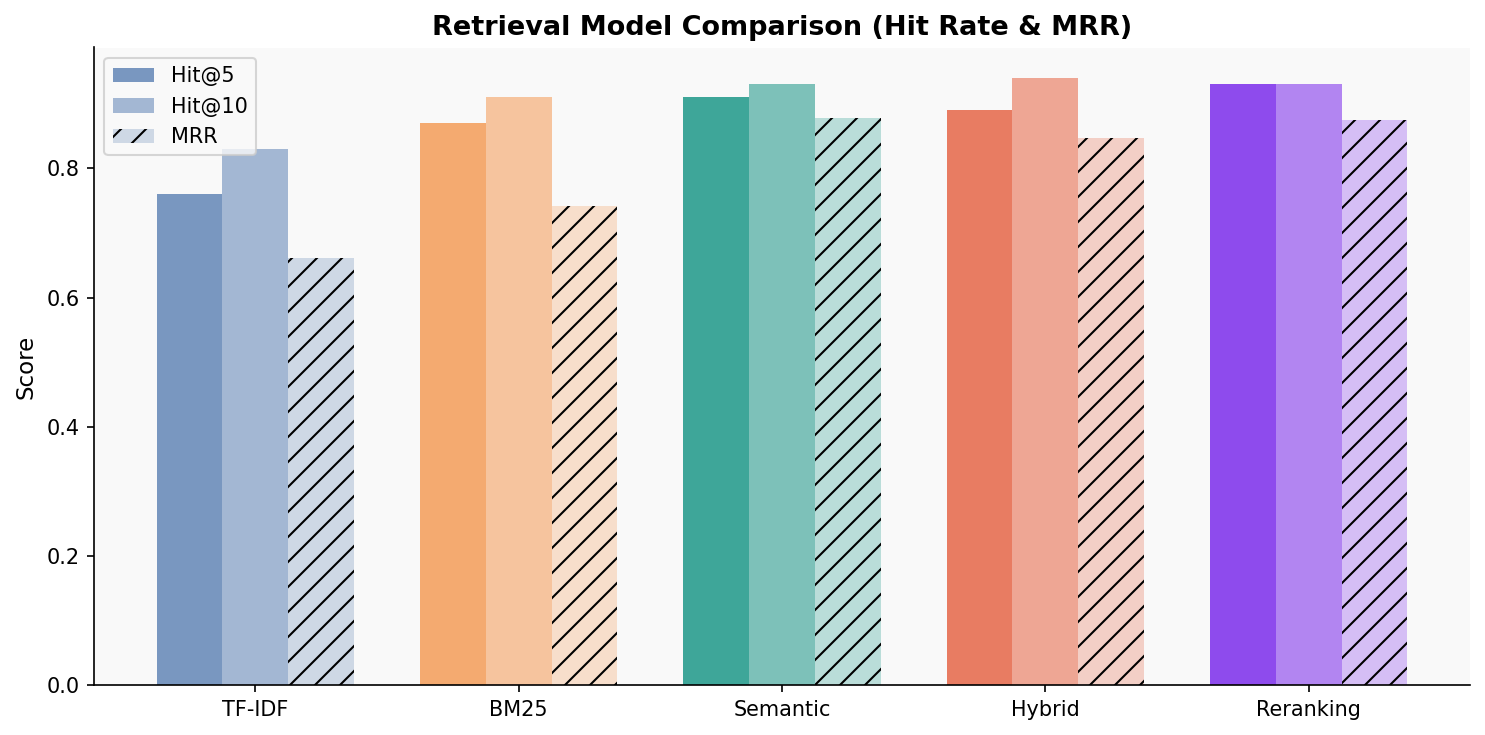

✓ Saved: reports/figures/eval_precision_bar.png


In [19]:
x = np.arange(len(summary))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, summary['Hit@5'], width, label='Hit@5', color=[MODEL_COLORS[m] for m in summary.index], alpha=0.9)
ax.bar(x, summary['Hit@10'], width, label='Hit@10', color=[MODEL_COLORS[m] for m in summary.index], alpha=0.6)
ax.bar(x + width, summary['MRR'], width, label='MRR', color=[MODEL_COLORS[m] for m in summary.index], alpha=0.3, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(summary.index)
ax.set_title('Retrieval Model Comparison (Hit Rate & MRR)', fontweight='bold')
ax.set_ylabel('Score')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(FIGURE_PATH / 'eval_precision_bar.png')
plt.show()
print(f"✓ Saved: {FIGURE_PATH / 'eval_precision_bar.png'}")

## 9. Vẽ Biểu đồ so sánh Độ trễ vs Độ chính xác

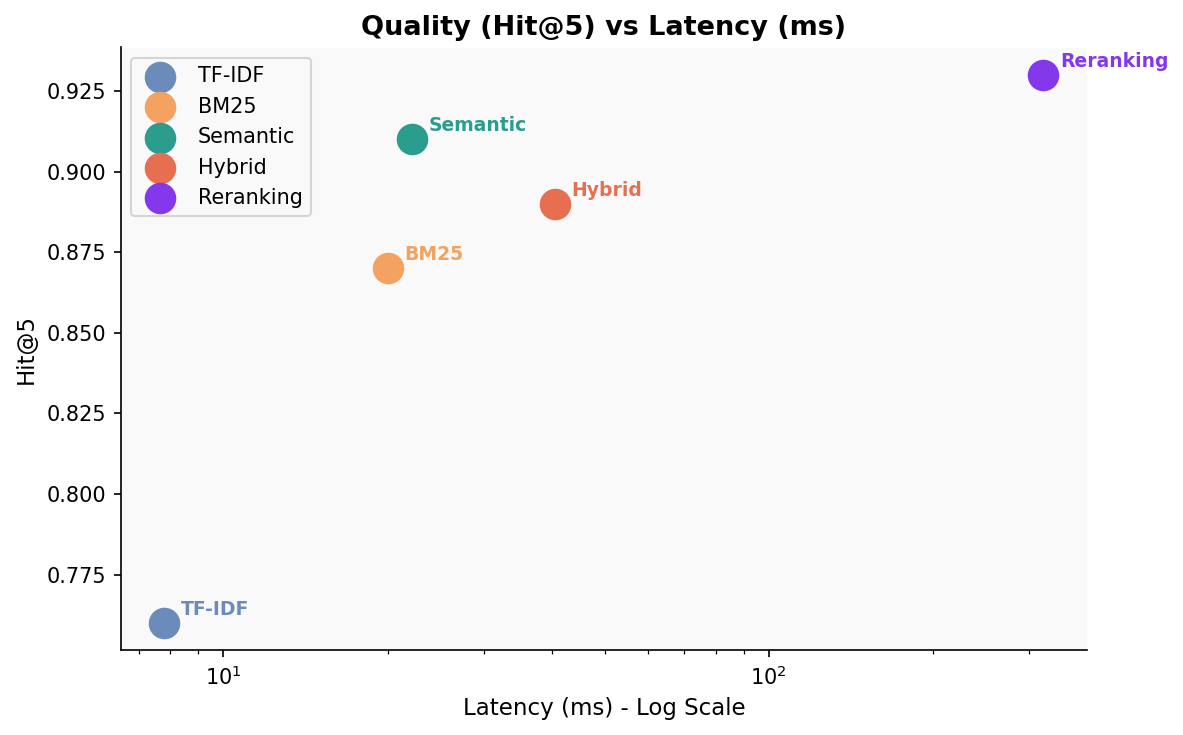

✓ Saved: reports/figures/eval_latency_quality.png


In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
for m in summary.index:
    ax.scatter(summary.loc[m, 'Latency (ms)'], summary.loc[m, 'Hit@5'], s=200, color=MODEL_COLORS[m], label=m)
    ax.annotate(
        m,
        xy=(summary.loc[m, 'Latency (ms)'], summary.loc[m, 'Hit@5']),
        xytext=(8, 4), textcoords='offset points',
        fontsize=9, fontweight='bold', color=MODEL_COLORS[m]
    )

ax.set_xscale('log')
ax.set_xlabel('Latency (ms) - Log Scale')
ax.set_ylabel('Hit@5')
ax.set_title('Quality (Hit@5) vs Latency (ms)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_PATH / 'eval_latency_quality.png')
plt.show()
print(f"✓ Saved: {FIGURE_PATH / 'eval_latency_quality.png'}")

## 10. Lưu Báo cáo JSON

In [21]:
final_report = {
    'results': summary.to_dict(orient='index'),
    'per_query': df_eval.to_dict(orient='records')
}
with open(REPORT_PATH / 'evaluation_final.json', 'w', encoding='utf-8') as f:
    json.dump(final_report, f, indent=2)
print(f"✓ Saved final report JSON to: {REPORT_PATH / 'evaluation_final.json'}")

✓ Saved final report JSON to: reports/evaluation_final.json
